# Article calculations — didactic reproduction, from raw data to published number

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fzampirolli/cs1-ai-methodology-reproducibility/blob/main/analise/artigo_calculos.ipynb)

**What this notebook does.** Recomputes, step by step, *every* quantitative
result in the article *"Active Learning with AI Support in CS1"*, starting
from the original response files (Google Forms/Sheets and the per-class
grade spreadsheet). Each section ends with a **📄 In the article** block
saying where that number appears (section, table, or figure).

**Inputs.**

| file | content | used in |
|---|---|---|
| `dados/serie-historica/pi0505_turmas_2009-2026.csv` | grades (A-D, F, O, Incomplete, No grade) per PI class, 2009.3-2026.2, class code redacted except for this article's own classes | Part 1 (historical series) |
| `dados/anonymous/perfil_diurno.csv` | profile — daytime class (Instructor B) | Part 2 (employment status) |
| `dados/anonymous/perfil_noturno.csv` | profile — evening classes (Instructor A) | Part 2 |
| `dados/anonymous/avaliacao_exp2_exp3.csv` | Likert 1-5 — Experiments 2 and 3, class/instructor already resolved | Part 3 (perception) |
| `dados/anonymous/avaliacao_exp1.csv` | Likert 1-5 — Experiment 1 | Part 3 |

> ⚠️ **Personal data.** The files in `dados/anonymous/` are generated from
> `dados/brutos/` (not version-controlled; carries e-mail/name, LGPD) by
> `analise/gen_dados_anonymous.py`, which drops the timestamp, name,
> e-mail, and every free-text field not used in the analysis, and resolves
> the class/instructor without real names. This notebook runs entirely
> from the already-anonymised data and still checks that no PII column is
> left (`drop_pii`), never printing individual rows.

**Labels (same as in the article).** Experiment 1 = Instructor A, evening, Campus 1, partial adoption, $N=16$ (exploratory).
Experiment 2 = Instructor B, daytime, Campus 1, $N=34$.
Experiment 3 = Instructor C, evening, Campus 2, $N=40$.
Confirmatory analysis = Experiments 2+3 ($N=74$).

In [1]:
# --- Setup -----------------------------------------------------------------
from pathlib import Path
import re, textwrap, warnings
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# Cosmetic-only warnings (pandas groupby-apply deprecation notice, GLM
# rank-deficiency notice expected from the year fixed effects, matplotlib
# tight_layout on the dendrogram) -- none affect a computed value, and the
# check(...) calls below independently confirm every result against the
# article regardless.
warnings.filterwarnings("ignore")

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
RNG = np.random.default_rng(20260901)          # fixed seed (bootstrap / Monte Carlo)

# repository root (works from analise/, from the root, or -- via the "Open
# in Colab" badge above -- from a fresh runtime with neither: clone the
# public repo once and switch into it).
ROOT = Path.cwd()
if not (ROOT / "dados").is_dir() and not (ROOT.parent / "dados").is_dir():
    import subprocess
    REPO = "cs1-ai-methodology-reproducibility"
    if not Path(REPO).is_dir():
        subprocess.run(["git", "clone", "--depth", "1",
                        f"https://github.com/fzampirolli/{REPO}.git"], check=True)
    import os
    os.chdir(f"{REPO}/analise")
    ROOT = Path.cwd()
if not (ROOT / "dados").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "dados").is_dir(), f"couldn't find dados/ from {Path.cwd()}"
SERIE = ROOT / "dados" / "serie-historica"
BRUTOS = ROOT / "dados" / "brutos"
ANON = ROOT / "dados" / "anonymous"
print("ROOT =", ROOT)

PII_TOKENS = ("carimbo", "data/hora", "timestamp", "nome complet",
              "email", "e-mail", "\ufeff")
def drop_pii(df):
    # Removes identifying columns (name / e-mail / timestamp) and returns
    # (clean_df, removed_columns). Questionnaire item columns -- the ones
    # with '[...]' in the header -- are never an identifier (item Q09's
    # wording mentions "e-mail", for instance) and are always kept.
    def is_pii(c):
        c = str(c)
        if "[" in c and "]" in c:
            return False
        cl = c.lower()
        return any(t in cl for t in PII_TOKENS)
    rm = [c for c in df.columns if is_pii(c)]
    return df.drop(columns=rm), rm

def check(name, obtained, expected, tol=0.05):
    "Checks a number against the article's value (fails loudly if it diverges)."
    ok = abs(float(obtained) - float(expected)) <= tol
    print(f"  [{'OK ' if ok else 'XX '}] {name}: obtained={obtained}  article≈{expected}")
    assert ok, f"{name}: {obtained} != {expected} (tol {tol})"


ROOT = /home/fz/VSCode/artigo-pi-2026-1


---
# Part 1 — Historical failure rate by class shift

Covers **§4.1** (structural cuts: term of offering and shift), **§4.2**
(*Failure rate by shift in the historical series*), **Table 6** (failure
rate by year and shift), and **Figure 3** (series by term).

Idea: reconstruct, at class level, the failure-rate series for PI (legacy
code `BC0505`/`BCM0505`) from 2009 to 2026.2, and check whether the evening
shift fails more than the daytime shift — controlling for year, the
pandemic window, campus, and on-schedule term.

### 1.1 Reading the (already de-identified) per-class table

In [2]:
d = pd.read_csv(SERIE / "pi0505_turmas_2009-2026.csv", dtype={"quadrimestre": str})
d = d.rename(columns={
    "turma": "class_id", "quadrimestre": "term", "turno": "shift",
    "periodo_ideal": "on_schedule", "n_avaliados": "n_assessed",
    "n_aprovados": "n_passed", "n_reprovados": "n_failed",
    "taxa_reprov": "failure_rate",
})
d["shift"] = d["shift"].map({"diurno": "daytime", "noturno": "evening"})
d["campus"] = d["campus"].map({"SA": "Campus 1", "SBC": "Campus 2"}).fillna("")
d["year"] = d["term"].str[:4].astype(int)
print("classes in the table:", len(d))
d[["term", "class_id", "shift", "campus", "on_schedule", "n_assessed", "n_failed"]].head(4)


classes in the table: 840


,term,class_id,shift,campus,on_schedule,n_assessed,n_failed
0,2009.3,NaN,daytime,,1,29,7
1,2009.3,NaN,daytime,,1,29,6
2,2009.3,NaN,daytime,,1,28,13
3,2009.3,NaN,daytime,,1,30,15


### 1.2 What this table already is, and what was redacted

This is `analise/00_serie_historica_extrair.py`'s output, not the raw
institutional export: deduplicated, with `shift` (1st letter of the class
code, `D…`/`N…`) and `campus` (`…SA`/`…SB` suffix) already derived from the
real class code, and only classes with $\ge 1$ grade recorded
(`n_assessed > 0`) kept — 2 classes with no identifiable shift were
dropped upstream (one a test row from the export).

**Class codes are redacted.** The real code (letter + sequence number + curriculum suffix + campus suffix) is
reused every term as a sequential slot number, not a name — but for
2026.1 specifically, it can be looked up against the institution's public
class schedule to identify the instructor, which would break double-blind
review. So `class_id` is blank for all 840 classes **except** the five
2026.1 classes that this article's Table 5 already discusses by number,
pseudonymised to match: `A1`/`A2` (Experiment 1, Instructor A), `B1`
(Experiment 2, Instructor B), `C1`/`C2` (Experiment 3, Instructor C).
Note that this institutional record's own assessed/failed counts for
`A1`/`A2` don't exactly match Table 5's --- Table 5 sources Experiment
1's numbers from the instructor's own consolidated grade sheet instead
(see its note), a different snapshot of the same two classes.

In [3]:
check("number of classes with >=1 grade", len(d), 840, tol=0)
check("assessments summed", d["n_assessed"].sum(), 25797, tol=0)
check("period covered (2009.3 to 2026.2)", d["term"].min() == "2009.3"
      and d["term"].max() == "2026.2", True, tol=0)
print(d.loc[d.class_id.notna(), ["term", "class_id", "shift", "campus", "n_assessed", "n_failed"]]
      .to_string(index=False))


  [OK ] number of classes with >=1 grade: obtained=840  article≈840
  [OK ] assessments summed: obtained=25797  article≈25797
  [OK ] period covered (2009.3 to 2026.2): obtained=True  article≈True
  term class_id   shift   campus  n_assessed  n_failed
2026.1       B1 daytime Campus 1          43        12
2026.1       C1 evening Campus 2          38        31
2026.1       A1 evening Campus 1          30         2
2026.1       A2 evening Campus 1          38         8
2026.1       C2 evening Campus 2          40        34


### 1.3 On-schedule term = the term with the most classes in the year

The calendar has 3 terms/year; PI is recommended right after the
foundational courses. Instead of fixing "always `.1`", the **on-schedule
term** of each year is defined as the term with the **largest number of
classes** (the main offering) — already computed as `on_schedule` in the
table; recomputed independently below as a cross-check. This changes the
label in 2010, 2014, 2021, 2022, and 2023.

In [4]:
modal = d.groupby(["year", "term"]).size().reset_index(name="n_classes")
modal_term = modal.loc[modal.groupby("year")["n_classes"].idxmax()].set_index("year")["term"]
recomputed = (d["term"] == d["year"].map(modal_term)).astype(int)
assert (recomputed == d["on_schedule"]).all(), "recomputed on-schedule term doesn't match the table"
print("[OK ] recomputed on-schedule term matches the table's column for all 840 classes\n")

tab = modal_term.reset_index().rename(columns={"term": "on-schedule term"})
tab["ends in .1?"] = np.where(tab["on-schedule term"].str.endswith(".1"), "yes", "**no**")
print(tab.to_string(index=False))
print("\n on-schedule term:", int(d.on_schedule.sum()), "classes |",
      "other terms:", int((d.on_schedule == 0).sum()))


[OK ] recomputed on-schedule term matches the table's column for all 840 classes

 year on-schedule term ends in .1?
 2009           2009.3      **no**
 2010           2010.2      **no**
 2011           2011.1         yes
 2012           2012.1         yes
 2013           2013.1         yes
 2014           2014.2      **no**
 2015           2015.1         yes
 2016           2016.1         yes
 2017           2017.1         yes
 2018           2018.1         yes
 2019           2019.1         yes
 2020           2020.1         yes
 2021           2021.2      **no**
 2022           2022.2      **no**
 2023           2023.2      **no**
 2024           2024.1         yes
 2025           2025.1         yes
 2026           2026.1         yes

 on-schedule term: 673 classes | other terms: 167


### 1.4 Failure rate per class

In [5]:
glob = d["n_failed"].sum() / d["n_assessed"].sum()
print(f"global failure rate (pooled) = {glob:.4f}  ->  ~{glob*100:.0f}%")
check("global failure rate ~30%", round(glob*100), 30, tol=1)
d[["term", "class_id", "shift", "campus", "on_schedule",
   "n_assessed", "n_failed", "failure_rate"]].head(4)


global failure rate (pooled) = 0.3015  ->  ~30%
  [OK ] global failure rate ~30%: obtained=30  article≈30


,term,class_id,shift,campus,on_schedule,n_assessed,n_failed,failure_rate
0,2009.3,NaN,daytime,,1,29,7,0.241379
1,2009.3,NaN,daytime,,1,29,6,0.206897
2,2009.3,NaN,daytime,,1,28,13,0.464286
3,2009.3,NaN,daytime,,1,30,15,0.500000


### 1.5 *Pooled* failure rate — by shift, campus, on-schedule term, and by experiment

`pooled` = $\sum F{+}O$ over $\sum$ assessed (not the mean of per-class
rates). The last three blocks are the **historical baseline of each
experiment** (§4.1): since all three experiments run in an on-schedule
term (2026.1), each is compared against its own `campus x shift` bracket
within the on-schedule term.

In [6]:
def pool(x):
    return x["n_failed"].sum() / x["n_assessed"].sum()

print("— by shift —")
for t, g in d.groupby("shift"):
    print(f"  {t:8}: {len(g):3d} classes | pooled {pool(g):.4f} | class mean {g.failure_rate.mean():.4f}")

print("\n— by campus x shift (full series) —")
for cp in ["Campus 1", "Campus 2"]:
    g = d[d.campus == cp]
    rd, rn = pool(g[g["shift"] == "daytime"]), pool(g[g["shift"] == "evening"])
    print(f"  {cp}: daytime {rd:.4f} | evening {rn:.4f} | gap {(rn-rd)*100:+.1f} p.p.")

print("\n— by on-schedule term —")
for pi, lab in [(1, "on-schedule"), (0, "other terms")]:
    g = d[d.on_schedule == pi]
    print(f"  {lab:12}: {len(g):3d} classes | pooled {pool(g):.4f}"
          + (f" | daytime {pool(g[g['shift']=='daytime']):.4f} | evening {pool(g[g['shift']=='evening']):.4f}"
             if pi == 1 else ""))

print("\n— per-experiment baseline (on-schedule term x campus x shift) —")
di = d[d.on_schedule == 1]
base = {}
for exp, cp, tn in [("Exp. 2 (Instr. B)", "Campus 1", "daytime"),
                    ("Exp. 1 (Instr. A)", "Campus 1", "evening"),
                    ("Exp. 3 (Instr. C)", "Campus 2", "evening")]:
    g = di[(di.campus == cp) & (di["shift"] == tn)]
    base[exp] = pool(g)
    print(f"  {exp}: {cp}, {tn} -> {pool(g)*100:.1f}%  ({len(g)} classes)")

print()
check("daytime pooled 25.8%",  pool(d[d["shift"]=='daytime'])*100, 25.8, tol=0.15)
check("evening pooled 35.5%", pool(d[d["shift"]=='evening'])*100, 35.5, tol=0.15)
check("on-schedule pooled 27.5%", pool(d[d.on_schedule==1])*100, 27.5, tol=0.2)
check("other terms pooled 40.5%", pool(d[d.on_schedule==0])*100, 40.5, tol=0.3)
check("Exp.2 baseline (C1/daytime/on-schedule) 23.0%", base["Exp. 2 (Instr. B)"]*100, 23.0, tol=0.3)
check("Exp.1 baseline (C1/evening/on-schedule) 32.1%", base["Exp. 1 (Instr. A)"]*100, 32.1, tol=0.3)
check("Exp.3 baseline (C2/evening/on-schedule) 37.3%", base["Exp. 3 (Instr. C)"]*100, 37.3, tol=0.3)


— by shift —
  daytime : 447 classes | pooled 0.2578 | class mean 0.2618
  evening : 393 classes | pooled 0.3552 | class mean 0.3656

— by campus x shift (full series) —
  Campus 1: daytime 0.2598 | evening 0.3415 | gap +8.2 p.p.
  Campus 2: daytime 0.2474 | evening 0.4008 | gap +15.3 p.p.

— by on-schedule term —
  on-schedule : 673 classes | pooled 0.2752 | daytime 0.2282 | evening 0.3320
  other terms : 167 classes | pooled 0.4049

— per-experiment baseline (on-schedule term x campus x shift) —
  Exp. 2 (Instr. B): Campus 1, daytime -> 23.0%  (255 classes)
  Exp. 1 (Instr. A): Campus 1, evening -> 32.1%  (238 classes)
  Exp. 3 (Instr. C): Campus 2, evening -> 37.3%  (62 classes)

  [OK ] daytime pooled 25.8%: obtained=25.77943556900556  article≈25.8
  [OK ] evening pooled 35.5%: obtained=35.51950293406973  article≈35.5
  [OK ] on-schedule pooled 27.5%: obtained=27.523828049017702  article≈27.5
  [OK ] other terms pooled 40.5%: obtained=40.49302503344162  article≈40.5
  [OK ] Exp.2 b

**📄 In the article.** §4.1 — "27.5% in on-schedule-term classes and
40.5% in the rest"; "daytime 22.8%; evening 33.2%" (on-schedule-term
bracket by shift); "23.0% … 32.1% … 37.3%" (baseline of each experiment);
"Campus 1: 26.0% (daytime) *vs.* 34.2% (evening); Campus 2: 24.7% *vs.*
40.1%". §4.2 — "25.8% in daytime classes (447 classes) and 35.5% in
evening classes (393 classes)".

### 1.6 Table 6 — failure rate by year and shift

In [7]:
rows = []
for year, g in d.groupby("year"):
    gd, gn = g[g["shift"] == "daytime"], g[g["shift"] == "evening"]
    rd = pool(gd) if len(gd) else np.nan
    rn = pool(gn) if len(gn) else np.nan
    rows.append((year, rd, rn, (rn - rd) * 100, len(g)))
tab6 = pd.DataFrame(rows, columns=["year", "daytime", "evening", "diff_pp", "classes"])
glb = (d["shift"] == "daytime"), (d["shift"] == "evening")
tab6.loc[len(tab6)] = ("Global", pool(d[glb[0]]), pool(d[glb[1]]),
                       (pool(d[glb[1]]) - pool(d[glb[0]])) * 100, len(d))
print(tab6.to_string(index=False,
      formatters={"daytime": "{:.2f}".format, "evening": "{:.2f}".format,
                  "diff_pp": "{:+.1f}".format}))

years = tab6[tab6.year != "Global"]
n_evening_higher = (years.evening > years.daytime).sum()
print(f"\n evening > daytime in {n_evening_higher}/{len(years)} years "
      f"| yearly difference between {years.diff_pp.min():.1f} and {years.diff_pp.max():.1f} p.p.")
check("evening > daytime in every year", n_evening_higher, len(years), tol=0)


  year daytime evening diff_pp  classes
  2009    0.23    0.27    +4.0       34
  2010    0.30    0.39    +8.8       13
  2011    0.24    0.34   +10.3       58
  2012    0.31    0.37    +5.9       56
  2013    0.25    0.36   +11.3       51
  2014    0.26    0.37   +11.3       47
  2015    0.27    0.31    +3.9       55
  2016    0.24    0.31    +6.5       51
  2017    0.26    0.29    +2.9       53
  2018    0.30    0.35    +5.1       50
  2019    0.27    0.46   +19.5       52
  2020    0.27    0.39   +11.7       40
  2021    0.27    0.28    +1.2       34
  2022    0.23    0.29    +5.9       53
  2023    0.16    0.26   +10.8       38
  2024    0.19    0.38   +19.4       49
  2025    0.30    0.44   +13.9       57
  2026    0.29    0.40   +10.6       49
Global    0.26    0.36    +9.7      840

 evening > daytime in 18/18 years | yearly difference between 1.2 and 19.5 p.p.
  [OK ] evening > daytime in every year: obtained=18  article≈18


**📄 In the article.** Table 6 and §4.1 — "all 18 years"; "yearly
difference between 1.2 and 19.5 percentage points".

### 1.7 Paired Wilcoxon test by term

Each term is a block: the evening *pooled* rate is compared to the
daytime rate in the **same** term (only terms that had both shifts).
$H_1$: evening > daytime (one-sided). Sign test as an auxiliary check.

In [8]:
piv = (d.groupby(["term", "shift"])
         .apply(lambda x: x.n_failed.sum() / x.n_assessed.sum())
         .unstack("shift").dropna())
diff = piv["evening"] - piv["daytime"]
w_series = stats.wilcoxon(diff, alternative="greater")
sg = stats.binomtest((diff > 0).sum(), len(diff), 0.5, alternative="greater")
print(f"terms with both shifts: {len(piv)}")
print(f"evening > daytime in {(diff>0).sum()}/{len(diff)}  "
      f"(median difference = {diff.median()*100:+.1f} p.p.)")
print(f"Paired Wilcoxon (H1: evening>daytime):  W = {w_series.statistic:.0f}   p = {w_series.pvalue:.2e}")
print(f"Sign test:  p = {sg.pvalue:.2e}")
check("29 of 32 terms", (diff > 0).sum(), 29, tol=0)
check("median difference 10.4 p.p.", diff.median()*100, 10.4, tol=0.3)


terms with both shifts: 32
evening > daytime in 29/32  (median difference = +10.4 p.p.)
Paired Wilcoxon (H1: evening>daytime):  W = 508   p = 8.64e-08
Sign test:  p = 1.28e-06
  [OK ] 29 of 32 terms: obtained=29  article≈29
  [OK ] median difference 10.4 p.p.: obtained=10.358053715502786  article≈10.4


**📄 In the article.** §4.2 — "$p < 10^{-7}$; evening higher in 29 of
32 terms, median difference of 10.4 percentage points".

### 1.8 Weighted binomial GLM + robustness

Model: $\text{failed} \sim \text{shift} + C(\text{year}) + C(\text{COVID
window})$, binomial response (successes = failures, failures = passes)
weighted by class size, with **cluster-robust standard errors grouped by
term**. The **odds ratio (OR)** evening *vs.* daytime is reported. Then,
the same model with **campus** and with **on-schedule term** as a
covariate.
> The records don't identify the instructor of each class → **no**
> instructor random effect; year enters as a block and the SE is
> clustered by term.

In [9]:
COVID = {q for q in {f"{y}.{k}" for y in (2020, 2021, 2022) for k in (1, 2, 3)}
         if "2020.1" <= q <= "2022.2"}
d["covid_window"] = np.where(d.term.isin(COVID), "covid",
                     np.where(d.term < "2020.1", "pre", "post"))
d["failures"] = d.n_failed.astype(int)
d["passes"] = (d.n_assessed - d.n_failed).astype(int)

def glm_or(formula, dat):
    m = smf.glm(formula, data=dat, family=sm.families.Binomial()).fit(
        cov_type="cluster", cov_kwds={"groups": dat["term"]})
    par = m.params.filter(like="shift")
    ci = m.conf_int().loc[par.index]
    return float(np.exp(par.iloc[0])), tuple(np.exp(ci.iloc[0])), float(m.pvalues[par.index].iloc[0]), m

BASE = "failures + passes ~ C(shift, Treatment('daytime')) + C(year) + C(covid_window, Treatment('pre'))"
or0, ci0, p0, m0 = glm_or(BASE, d)
print(f"base GLM           : OR = {or0:.3f}  95% CI [{ci0[0]:.3f}; {ci0[1]:.3f}]  p = {p0:.2e}")

dc = d[d.campus.isin(["Campus 1", "Campus 2"])]
or1, ci1, p1, _ = glm_or(BASE + " + C(campus, Treatment('Campus 1'))", dc)
print(f"+ campus            : OR = {or1:.3f}  95% CI [{ci1[0]:.3f}; {ci1[1]:.3f}]  p = {p1:.2e}")

or2, ci2, p2, m2 = glm_or(BASE + " + on_schedule", d)
or_os = float(np.exp(m2.params["on_schedule"]))
print(f"+ on-schedule term  : OR = {or2:.3f}  95% CI [{ci2[0]:.3f}; {ci2[1]:.3f}]  p = {p2:.2e}")
print(f"                     (OR on-schedule vs other terms = {or_os:.3f})")

check("base OR ~1.57", or0, 1.57, tol=0.03)
check("+ campus OR ~1.59", or1, 1.59, tol=0.03)
check("+ on-schedule term OR ~1.58", or2, 1.58, tol=0.03)
check("on-schedule term OR ~0.54", or_os, 0.54, tol=0.03)


base GLM           : OR = 1.574  95% CI [1.404; 1.765]  p = 8.43e-15


+ campus            : OR = 1.592  95% CI [1.416; 1.790]  p = 6.93e-15


+ on-schedule term  : OR = 1.584  95% CI [1.421; 1.766]  p = 1.22e-16
                     (OR on-schedule vs other terms = 0.536)
  [OK ] base OR ~1.57: obtained=1.5738333917472516  article≈1.57
  [OK ] + campus OR ~1.59: obtained=1.5922468644370953  article≈1.59
  [OK ] + on-schedule term OR ~1.58: obtained=1.5840954733842687  article≈1.58
  [OK ] on-schedule term OR ~0.54: obtained=0.5357765822535199  article≈0.54


**📄 In the article.** §4.2 — OR **1.57** [1.40; 1.76]; "The
additional adjustment for campus … odds ratio of 1.59"; "Including the
on-schedule term … odds ratio of 1.58 … nearly halving the odds of
failure (odds ratio of 0.54)".

### 1.9 Scheirer-Ray-Hare — shift x pandemic window

A non-parametric alternative to two-way ANOVA, on the **per-class rate**
(ranks). Checks for a main effect of shift, an effect of the COVID
window, and an interaction.

In [10]:
def scheirer_ray_hare(df, y, f1, f2):
    x = df[[y, f1, f2]].dropna().copy()
    N = len(x)
    x["R"] = stats.rankdata(x[y])
    ss_total = ((x["R"] - x["R"].mean()) ** 2).sum()
    ms_total = ss_total / (N - 1)
    def ss(cols):
        g = x.groupby(cols)["R"]
        return (g.count() * (g.mean() - x["R"].mean()) ** 2).sum()
    ss_a, ss_b = ss(f1), ss(f2)
    ss_inter = ss([f1, f2]) - ss_a - ss_b
    la, lb = x[f1].nunique(), x[f2].nunique()
    out = {}
    for name, s, dof in [(f1, ss_a, la - 1), (f2, ss_b, lb - 1),
                         ("interaction", ss_inter, (la - 1) * (lb - 1))]:
        H = s / ms_total
        out[name] = (H, dof, stats.chi2.sf(H, dof))
    return out

for name, (H, dof, p) in scheirer_ray_hare(d, "failure_rate", "shift", "covid_window").items():
    print(f"  {name:12}: H = {H:6.2f}  df = {dof}  p = {p:.2e}")
srh = scheirer_ray_hare(d, "failure_rate", "shift", "covid_window")
check("SRH shift H ~51.9", srh["shift"][0], 51.9, tol=1.0)
check("SRH window p (not signif.)", srh["covid_window"][2] > 0.05, True, tol=0)


  shift       : H =  51.90  df = 1  p = 5.85e-13
  covid_window: H =   3.46  df = 2  p = 1.78e-01
  interaction : H =   1.63  df = 2  p = 4.43e-01
  [OK ] SRH shift H ~51.9: obtained=51.8965481108157  article≈51.9
  [OK ] SRH window p (not signif.): obtained=True  article≈True


**📄 In the article.** §4.2 — "a strong main effect of shift ($H =
51.9$; $p < 10^{-12}$), with no detectable effect of the pandemic window
($p = 0.18$) nor interaction ($p = 0.44$)".

### 1.10 Figure 3 — failure-rate series by term

-> /home/fz/VSCode/artigo-pi-2026-1/figuras/fig_serie_turno_en.pdf


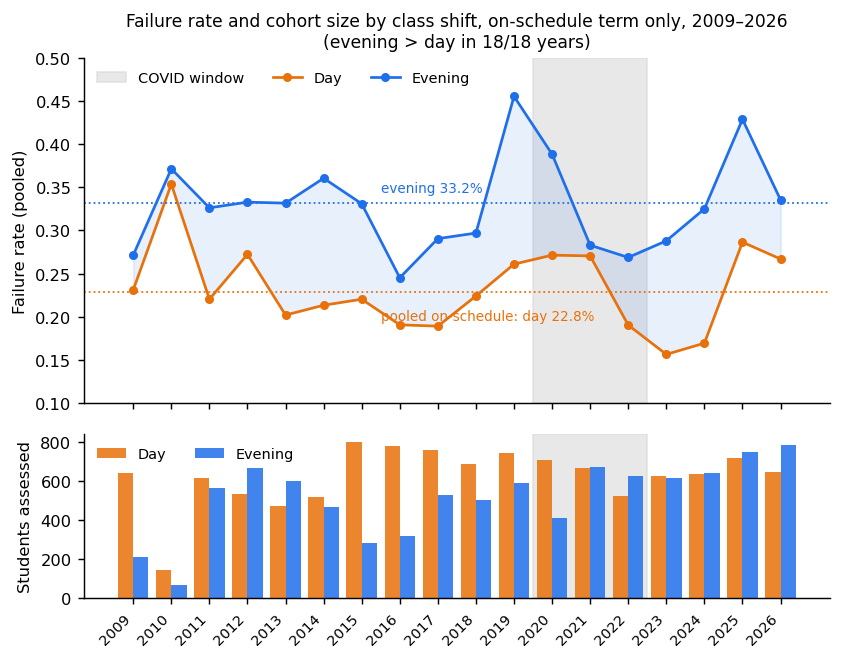

In [11]:
# Rendered by calling the article's own plotting code directly (not a
# reimplementation here), so the figure below is pixel-identical to the one
# in the manuscript.
import importlib.util
from IPython.display import Image, display

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

figs = load_module("figuras_en", ROOT / "analise" / "03_figuras_en.py")
figs.fig_serie_turno()
display(Image(filename=str(ROOT / "figuras" / "fig_serie_turno_en.png")))


**📄 In the article.** Figure 3 (`figuras/fig_serie_turno_en.pdf`,
generated by `analise/03_figuras_en.py::fig_serie_turno` — called directly
above, restricted to the on-schedule term of each year, as in the
published figure).

### 1.11 Figure 4 — failure rate by shift, year by year: on-schedule vs. other terms

Reopens the series by **term of offering**: within each year, the
on-schedule term (most classes) *vs.* the rest. For each split, computes
the daytime/evening *pooled* rate with a **95% Wilson CI**, the count of
years where evening fails more (inversions = years with few classes), and
the shift **odds ratio (OR)**.

In [12]:
def wilson(k, n, z=1.96):
    "Wilson CI for a proportion (k successes out of n)."
    if not n:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z * z / n
    center = p + z * z / (2 * n)
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return ((center - half) / den, (center + half) / den)

def odds_ratio(p_num, p_den):
    "OR = odds(num) / odds(den)."
    return (p_num / (1 - p_num)) / (p_den / (1 - p_den))

term_split = {}
for pi, lab in [(1, "on-schedule"), (0, "other terms")]:
    g = d[d.on_schedule == pi]
    rec = {}
    for shift, gg in g.groupby("shift"):
        k, n = int(gg.n_failed.sum()), int(gg.n_assessed.sum())
        rec[shift] = dict(k=k, n=n, rate=k / n, ci=wilson(k, n))
    piv = g.pivot_table(index="year", columns="shift",
                        values=["n_failed", "n_assessed"], aggfunc="sum")
    dr = piv[("n_failed", "daytime")] / piv[("n_assessed", "daytime")]
    er = piv[("n_failed", "evening")] / piv[("n_assessed", "evening")]
    pa = pd.DataFrame({"daytime": dr, "evening": er}).dropna()
    rec["years_evening_higher"] = int((pa.evening > pa.daytime).sum())
    rec["years_total"] = int(len(pa))
    rec["or"] = odds_ratio(rec["evening"]["rate"], rec["daytime"]["rate"])
    term_split[lab] = rec
    lo_d, hi_d = rec["daytime"]["ci"]; lo_n, hi_n = rec["evening"]["ci"]
    print(f"{lab:12}: daytime {rec['daytime']['rate']*100:5.1f}% [{lo_d*100:.1f}-{hi_d*100:.1f}]  "
          f"evening {rec['evening']['rate']*100:5.1f}% [{lo_n*100:.1f}-{hi_n*100:.1f}]  "
          f"evening>daytime in {rec['years_evening_higher']}/{rec['years_total']} years  "
          f"OR = {rec['or']:.2f}")

check("on-schedule: daytime pooled ~22.8%", term_split["on-schedule"]["daytime"]["rate"]*100, 22.8, tol=0.3)
check("on-schedule: evening pooled ~33.2%", term_split["on-schedule"]["evening"]["rate"]*100, 33.2, tol=0.3)
check("on-schedule: evening>daytime in 18/18 years", term_split["on-schedule"]["years_evening_higher"],
      term_split["on-schedule"]["years_total"], tol=0)
check("on-schedule: OR pooled ~1.7", term_split["on-schedule"]["or"], 1.7, tol=0.1)
check("other terms: daytime pooled ~37.0%", term_split["other terms"]["daytime"]["rate"]*100, 37.0, tol=0.5)
check("other terms: evening pooled ~45.0%", term_split["other terms"]["evening"]["rate"]*100, 45.0, tol=0.5)
check("other terms: evening>daytime in 10/14 years", term_split["other terms"]["years_evening_higher"], 10, tol=0)
check("other terms: OR pooled ~1.4", term_split["other terms"]["or"], 1.4, tol=0.1)


on-schedule : daytime  22.8% [22.1-23.6]  evening  33.2% [32.3-34.2]  evening>daytime in 18/18 years  OR = 1.68
other terms : daytime  37.0% [35.3-38.8]  evening  45.0% [43.0-47.1]  evening>daytime in 10/14 years  OR = 1.39
  [OK ] on-schedule: daytime pooled ~22.8%: obtained=22.819806204996  article≈22.8
  [OK ] on-schedule: evening pooled ~33.2%: obtained=33.20450885668277  article≈33.2
  [OK ] on-schedule: evening>daytime in 18/18 years: obtained=18  article≈18
  [OK ] on-schedule: OR pooled ~1.7: obtained=1.6812946307991163  article≈1.7
  [OK ] other terms: daytime pooled ~37.0%: obtained=37.027027027027025  article≈37.0
  [OK ] other terms: evening pooled ~45.0%: obtained=45.006599208095025  article≈45.0
  [OK ] other terms: evening>daytime in 10/14 years: obtained=10  article≈10
  [OK ] other terms: OR pooled ~1.4: obtained=1.3918773722627735  article≈1.4


-> /home/fz/VSCode/artigo-pi-2026-1/figuras/fig_serie_turno_periodo_en.pdf


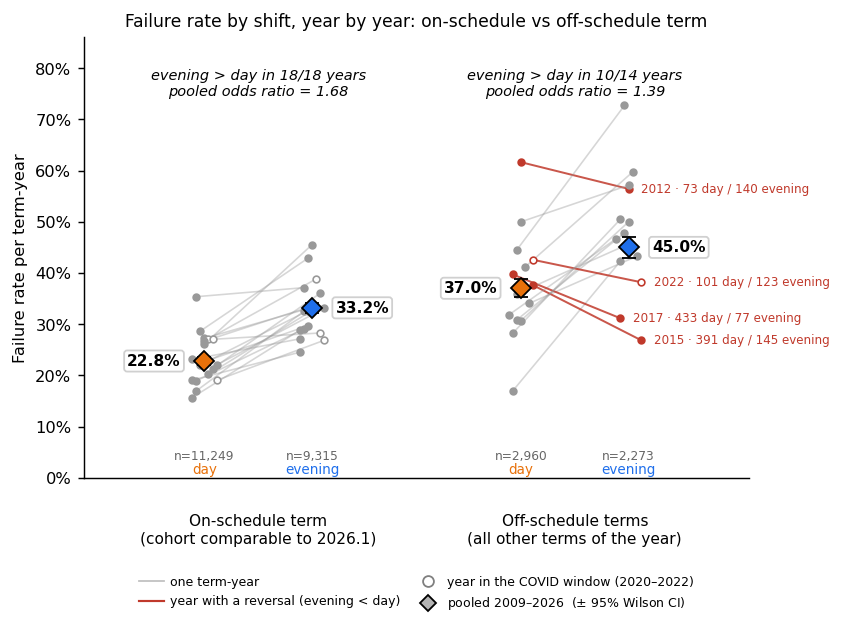

In [13]:
# Same principle as Figure 3 above: this calls the article's own
# plotting function, so it reproduces the published year-by-year
# slopegraph exactly (reversal years in red, pooled rate + 95% Wilson CI
# as diamonds), not a simplified stand-in.
figs.fig_serie_turno_periodo()
display(Image(filename=str(ROOT / "figuras" / "fig_serie_turno_periodo_en.png")))


**📄 In the article.** Figure 4 (`figuras/fig_serie_turno_periodo_en.pdf`,
generated by `analise/03_figuras_en.py::fig_serie_turno_periodo` — called
directly above). §4.1 — "daytime 22.8%; evening 33.2%" (on-schedule, 18/18
years, OR ≈ 1.7) *vs.* "37.0% … 45.0%" (other terms, 10/14 years, OR ≈
1.4).

---
# Part 2 — Class profile (§4.1 and §4.4)

From the **Student Profile** questionnaire (2026.1). Daytime side =
Instructor B's class (Experiment 2); evening side = Instructor A's classes
(Experiment 1) — Instructor C did not respond to the profile survey. §4.1
uses employment status; **Table 8** (§4.4) adds study time, entry year,
and prior programming exposure.

In [14]:
def load_profile(name):
    df = pd.read_csv(ANON / name)
    df, rm = drop_pii(df)                             # check: should already be empty
    tcol = next(c for c in df.columns if str(c).strip().lower() == "turma")
    df = df[df[tcol].notna()].copy()                 # drop responses without a class
    print(f"{name[:45]:45}  {len(df):3d} responses (with class) | PII removed: {rm}")
    return df

perf_day = load_profile("perfil_diurno.csv")   # Instructor B, daytime
perf_eve = load_profile("perfil_noturno.csv")  # Instructor A, evening

def count_employment(df, label):
    col = next(c for c in df.columns if "trabalha" in str(c).lower())
    v = df[col].astype(str).str.strip()
    v = v[v.isin(["Sim", "Não"])]                     # ignore typing noise
    yes, no, n = (v == "Sim").sum(), (v == "Não").sum(), len(v)
    print(f"{label:30}: {n} valid responses | not employed {no} ({no/n:.0%}) | employed {yes} ({yes/n:.0%})")
    return no, yes, n

no_d, yes_d, n_d = count_employment(perf_day, "Daytime (Exp. 2, Instr. B)")
no_e, yes_e, n_e = count_employment(perf_eve, "Evening (Exp. 1, Instr. A)")
print()
check("daytime: 81% not employed", no_d / n_d * 100, 81, tol=1.5)
check("evening: 79% employed",    yes_e / n_e * 100, 79, tol=1.5)
check("n daytime = 37", n_d, 37, tol=0);  check("n evening = 28", n_e, 28, tol=0)


perfil_diurno.csv                               37 responses (with class) | PII removed: []
perfil_noturno.csv                              28 responses (with class) | PII removed: []
Daytime (Exp. 2, Instr. B)    : 37 valid responses | not employed 30 (81%) | employed 7 (19%)
Evening (Exp. 1, Instr. A)    : 28 valid responses | not employed 6 (21%) | employed 22 (79%)

  [OK ] daytime: 81% not employed: obtained=81.08108108108108  article≈81
  [OK ] evening: 79% employed: obtained=78.57142857142857  article≈79
  [OK ] n daytime = 37: obtained=37  article≈37
  [OK ] n evening = 28: obtained=28  article≈28


**📄 In the article.** §4.1 — "81% of the 37 respondents in the
daytime class (Experiment 2) reported not being employed, whereas in the
evening classes of Experiment 1, 79% of the 28 respondents work part- or
full-time".

### 2.2 Remaining rows of Table 8 (§4.4)

- **$\ge 3$ h/day for study**: column "How many hours a day can you access
  the internet for study?"; answers 3, 4, and "More than 4" are counted.
- **Entry in the year of offering**: column "When did you enter the
  institution?" $= 2025$.
- **No prior exposure**: languages-already-used column $=$ "Never used
  one".

In [15]:
def find_col(df, *keys):
    return next(c for c in df.columns if all(k in str(c).lower() for k in keys))

def pct(df, mask):
    return 100 * mask.sum() / len(df)

def profile_row(df):
    hours = df[find_col(df, "horas")].astype(str).str.strip()
    ge3 = hours.isin(["3", "3.0", "4", "4.0"]) | hours.str.contains("Mais que 4", case=False, na=False)
    year = pd.to_numeric(df[find_col(df, "quando", "ingress")].astype(str).str[:4], errors="coerce")
    prog = df[find_col(df, "linguagem de programa")].astype(str).str.strip().str.lower()
    none_ = prog.str.contains("nunca") | prog.isin(["", "nan", "não", "nao", "nenhuma"])
    bi = df[find_col(df, "bacharelado interdisciplinar")].astype(str).str.strip()
    return dict(n=len(df),
                employed=pct(df, df[find_col(df, "trabalha")].astype(str).str.strip().eq("Sim")),
                ge3h=pct(df, ge3),
                entry_year_of_offering=pct(df, year.eq(2025)),
                no_prior_exposure=pct(df, none_),
                same_BI=pct(df, bi.eq(bi.mode().iloc[0])))

tab8 = pd.DataFrame({"Daytime (Exp. 2)": profile_row(perf_day),
                     "Evening (Exp. 1)": profile_row(perf_eve)}).T
print(tab8.round(0).astype({"n": int}).to_string())
_day, _eve = tab8.loc["Daytime (Exp. 2)"], tab8.loc["Evening (Exp. 1)"]
check("daytime >=3h ~81%", _day.ge3h, 81, tol=2)
check("evening >=3h ~50%", _eve.ge3h, 50, tol=2)
check("daytime entry 2025 ~89%", _day.entry_year_of_offering, 89, tol=2)
check("evening entry 2025 ~61%", _eve.entry_year_of_offering, 61, tol=2)
check("evening no prior exposure ~7%", _eve.no_prior_exposure, 7, tol=2)
check("same BI = 100% in both", _day.same_BI + _eve.same_BI, 200, tol=0)


                   n  employed  ge3h  entry_year_of_offering  no_prior_exposure  same_BI
Daytime (Exp. 2)  37      19.0  81.0                    89.0                0.0    100.0
Evening (Exp. 1)  28      79.0  50.0                    61.0                7.0    100.0
  [OK ] daytime >=3h ~81%: obtained=81.08108108108108  article≈81
  [OK ] evening >=3h ~50%: obtained=50.0  article≈50
  [OK ] daytime entry 2025 ~89%: obtained=89.1891891891892  article≈89
  [OK ] evening entry 2025 ~61%: obtained=60.714285714285715  article≈61
  [OK ] evening no prior exposure ~7%: obtained=7.142857142857143  article≈7
  [OK ] same BI = 100% in both: obtained=200.0  article≈200


**📄 In the article.** Table 8 and §4.4 — daytime 19% employed, 81%
with $\ge 3$ h/day, 89% entered in the year of offering, 0% with no prior
exposure; evening 79% / 50% / 61% / 7%; same entry programme in both
(100%).

---
# Part 3 — Student perception (§4.3, Figures 4 and 5, Table 5)

Likert questionnaire from 1 (strongly disagree) to 5 (strongly agree), 3 =
neutral. Substantive items **Q01-Q17**; **Q18-Q20** are validity checkers.
The **confirmatory** analysis combines Experiments 2 and 3 ($N=74$);
Experiment 1 ($N=16$) is descriptive only.

### 3.1 Reading and labelling each respondent

In [16]:
av = pd.read_csv(ANON / "avaliacao_exp2_exp3.csv")
av, rm = drop_pii(av); print("Exp2+3 evaluation — PII columns removed:", rm)

def label_row(code):
    return {"B": ("Exp. 2", "B", "daytime"), "C": ("Exp. 3", "C", "evening")}.get(code, ("?", "?", "?"))
av[["experiment", "instructor", "shift"]] = av["instrutor"].map(label_row).tolist()

g1 = pd.read_csv(ANON / "avaliacao_exp1.csv")
g1, rm = drop_pii(g1); print("Exp1 evaluation — PII columns removed:", rm)
g1["experiment"], g1["instructor"], g1["shift"] = "Exp. 1", "A", "evening"

print("\nN per group:")
print(av["experiment"].value_counts().to_string())
print(f"Exp. 1               {len(g1)}")
print(f"Confirmatory (2+3)  {len(av)}")
check("N Exp. 2", (av.experiment == "Exp. 2").sum(), 34, tol=0)
check("N Exp. 3", (av.experiment == "Exp. 3").sum(), 40, tol=0)
check("N confirmatory", len(av), 74, tol=0)
check("N Exp. 1", len(g1), 16, tol=0)


Exp2+3 evaluation — PII columns removed: []
Exp1 evaluation — PII columns removed: []

N per group:
experiment
Exp. 3    40
Exp. 2    34
Exp. 1               16
Confirmatory (2+3)  74
  [OK ] N Exp. 2: obtained=34  article≈34
  [OK ] N Exp. 3: obtained=40  article≈40
  [OK ] N confirmatory: obtained=74  article≈74
  [OK ] N Exp. 1: obtained=16  article≈16


### 3.2 Identify the Likert item columns

Item column = has `[` `]` in the header and every value in
$\{1,2,3,4,5\}$. The number between brackets becomes `Q01`…`Q20`.

In [17]:
def likert_cols(df):
    out = []
    for c in df.columns:
        if "[" in str(c) and "]" in str(c):
            v = pd.to_numeric(df[c], errors="coerce").dropna()
            if len(v) and v.isin([1, 2, 3, 4, 5]).all():
                out.append(c)
    return out

def qid(c):
    m = re.search(r"\[\s*(\d{1,2})", str(c))
    return f"Q{int(m.group(1)):02d}" if m else str(c)[:10]

items = likert_cols(av)
QMAP = {qid(c): c for c in items}
print(f"{len(items)} Likert items:", ", ".join(sorted(QMAP)))
SUBST = [q for q in sorted(QMAP) if 1 <= int(q[1:]) <= 17]   # Q01..Q17
VALID = [q for q in sorted(QMAP) if int(q[1:]) >= 18]        # Q18..Q20
print("substantive:", SUBST)
print("validity checkers:", VALID)


20 Likert items: Q01, Q02, Q03, Q04, Q05, Q06, Q07, Q08, Q09, Q10, Q11, Q12, Q13, Q14, Q15, Q16, Q17, Q18, Q19, Q20
substantive: ['Q01', 'Q02', 'Q03', 'Q04', 'Q05', 'Q06', 'Q07', 'Q08', 'Q09', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17']
validity checkers: ['Q18', 'Q19', 'Q20']


### 3.3 Item normality (Shapiro-Wilk, D'Agostino, Jarque-Bera)

Discrete Likert scales are rarely normal; this is confirmed to justify the
use of non-parametric tests.

In [18]:
def col(df, q):  # numeric series for one item
    return pd.to_numeric(df[QMAP[q]], errors="coerce").dropna().to_numpy(float)

norm = []
for q in sorted(QMAP):
    x = col(av, q)
    sw = stats.shapiro(x).pvalue
    da = stats.normaltest(x).pvalue                 # D'Agostino & Pearson (K^2)
    jb = stats.jarque_bera(x).pvalue
    norm.append((q, sw, da, jb))
norm = pd.DataFrame(norm, columns=["item", "Shapiro_p", "DAgostino_p", "JarqueBera_p"])
print(norm.to_string(index=False, float_format="{:.4f}".format))
viol = (norm["Shapiro_p"] < 0.05).sum()
print(f"\n{viol}/{len(norm)} items violate normality (Shapiro, p<0.05)")
check("all 20 items violate normality", viol, len(norm), tol=0)


item  Shapiro_p  DAgostino_p  JarqueBera_p
 Q01     0.0000       0.0730        0.1451
 Q02     0.0000       0.0705        0.1015
 Q03     0.0000       0.0095        0.0064
 Q04     0.0000       0.0813        0.1190
 Q05     0.0000       0.0529        0.0533
 Q06     0.0000       0.0005        0.0001
 Q07     0.0000       0.0229        0.0250
 Q08     0.0000       0.0270        0.0756
 Q09     0.0000       0.8165        0.7536
 Q10     0.0000       0.0011        0.0006
 Q11     0.0000       0.0982        0.1648
 Q12     0.0000       0.0518        0.0501
 Q13     0.0001       0.1653        0.3803
 Q14     0.0000       0.0628        0.1097
 Q15     0.0000       0.0103        0.0080
 Q16     0.0000       0.1275        0.3318
 Q17     0.0000       0.0215        0.1123
 Q18     0.0000       0.0000        0.0000
 Q19     0.0000       0.0079        0.0278
 Q20     0.0000       0.0000        0.0000

20/20 items violate normality (Shapiro, p<0.05)
  [OK ] all 20 items violate normality: obtained

**📄 In the article.** §4.3 (Method/§ Statistical analysis) — "All
items violated the normality assumption by the Shapiro-Wilk test …
confirmed by the D'Agostino and Jarque-Bera tests".

### 3.4 One-sided Wilcoxon + Holm, effect size, and bootstrap CI

For each substantive item: signed-rank Wilcoxon on $(x-3)$, $H_1$: median
$> 3$; **Holm** correction over the 17 comparisons. Effect size = **rank-
biserial correlation** $r=\dfrac{T^+ - T^-}{T^+ + T^-}$ (thresholds 0.1 /
0.3 / 0.5 = small / medium / large). 95% CI of the median by **bootstrap**
(5,000 resamples).

In [19]:
def rank_biserial(x, mu=3):
    diff = x - mu; diff = diff[diff != 0]
    r = stats.rankdata(np.abs(diff))
    return float((r[diff > 0].sum() - r[diff < 0].sum()) / r.sum())

def boot_ci(x, n=5000, a=0.05):
    bs = np.median(RNG.choice(x, (n, x.size), replace=True), axis=1)
    return float(np.percentile(bs, 100*a/2)), float(np.percentile(bs, 100*(1-a/2)))

rows = []
for q in SUBST:
    x = col(av, q)
    w = stats.wilcoxon(x - 3, alternative="greater", zero_method="wilcox")
    lo, hi = boot_ci(x)
    rows.append(dict(item=q, n=x.size, median=np.median(x), mean=round(x.mean(), 2),
                     ci95=f"[{lo:.1f}; {hi:.1f}]", W=float(w.statistic),
                     p_raw=float(w.pvalue), r=round(rank_biserial(x), 2)))
conf = pd.DataFrame(rows)
conf["p_holm"] = multipletests(conf["p_raw"], method="holm")[1]
conf["signif"] = conf["p_holm"] < 0.05
conf["effect"] = pd.cut(conf["r"].abs(), [-1, .1, .3, .5, 1],
                        labels=["negligible", "small", "medium", "large"])
print(conf[["item", "n", "median", "mean", "ci95", "r", "effect", "p_raw", "p_holm", "signif"]]
      .to_string(index=False, float_format="{:.4f}".format))
n_sig = conf.signif.sum()
print(f"\n{n_sig}/17 items significant after Holm")
print("5 largest effects:", ", ".join(conf.nlargest(5, "r")["item"] + " (r=" +
      conf.nlargest(5, "r")["r"].round(2).astype(str) + ")"))
check("14/17 items significant", n_sig, 14, tol=0)


item  n  median   mean       ci95       r     effect  p_raw  p_holm  signif
 Q01 74  4.0000 3.5500 [3.0; 4.0]  0.5400      large 0.0002  0.0012    True
 Q02 74  4.0000 3.6800 [3.0; 4.0]  0.6400      large 0.0000  0.0001    True
 Q03 74  4.5000 3.9900 [4.0; 5.0]  0.7800      large 0.0000  0.0000    True
 Q04 74  4.0000 3.7000 [3.5; 4.0]  0.6800      large 0.0000  0.0000    True
 Q05 74  4.0000 4.0900 [4.0; 4.5]  0.9300      large 0.0000  0.0000    True
 Q06 74  5.0000 4.4100 [4.0; 5.0]  0.9800      large 0.0000  0.0000    True
 Q07 74  4.0000 3.8800 [4.0; 4.0]  0.7900      large 0.0000  0.0000    True
 Q08 74  4.0000 3.9500 [4.0; 4.0]  0.8600      large 0.0000  0.0000    True
 Q09 74  3.0000 3.0000 [3.0; 3.0] -0.0100 negligible 0.5214  1.0000   False
 Q10 74  4.0000 4.1600 [4.0; 5.0]  0.9000      large 0.0000  0.0000    True
 Q11 74  4.0000 3.4700 [3.0; 4.0]  0.4600     medium 0.0012  0.0061    True
 Q12 74  4.0000 3.8900 [4.0; 4.0]  0.8100      large 0.0000  0.0000    True
 Q13 74  3.0

**📄 In the article.** §4.3.1 — "Of the 17 substantive items
(Q01-Q17), **14 reached significance** … The five largest effects were:
Q06 … Q14 … Q05 … Q10 … Q08". Figure 5 = the `median`/`ci95`/`signif`
column of this table.

### 3.5 Instrument dimensions (score and consistency)

The 17 substantive items are assigned, *a priori*, to four dimensions
aligned with the ecosystem's layers (the "Dim." column of Table 5). For
each dimension: mean score (average of the items) and Cronbach's alpha.

In [20]:
DIM_ITEMS = {
    "D1 AI-curated material":       ["Q02", "Q11", "Q13", "Q16", "Q17"],
    "D2 guided active practice":         ["Q04", "Q05", "Q06", "Q07", "Q14"],
    "D3 autograding and feedback":["Q03", "Q08", "Q09", "Q10"],
    "D4 use and self-perception":          ["Q01", "Q12", "Q15"],
}
DIM_OF = {q: d[:2] for d, qs in DIM_ITEMS.items() for q in qs}   # Q06 -> 'D2'
MNEM = {"Q01": "used the materials", "Q02": "NotebookLM formats", "Q03": "Colab test cases",
        "Q04": "class opener", "Q05": "try alone first", "Q06": "in-class exercises",
        "Q07": "exercise load", "Q08": "VPL+AI feedback", "Q09": "AI e-mail feedback",
        "Q10": "exams on target", "Q11": "exam preparation", "Q12": "logic progress",
        "Q13": "worse without NotebookLM", "Q14": "theory + practice", "Q15": "would recommend NotebookLM",
        "Q16": "interest via NotebookLM", "Q17": "kept up despite difficulty"}

def cronbach(frame):
    m = frame.dropna().to_numpy(float)
    k = m.shape[1]
    return k / (k - 1) * (1 - m.var(axis=0, ddof=1).sum() / m.sum(axis=1).var(ddof=1))

rows = []
for name, qs in DIM_ITEMS.items():
    M = pd.DataFrame({q: col(av, q) for q in qs})
    rows.append(dict(dimension=name, items=len(qs),
                       mean_score=round(M.mean(axis=1).mean(), 2),
                       cronbach_alpha=round(cronbach(M), 2)))
dims = pd.DataFrame(rows)
print(dims.to_string(index=False))
highest = dims.loc[dims.mean_score.idxmax(), "dimension"][:2]
lowest = dims.loc[dims.mean_score.idxmin(), "dimension"][:2]
print(f"\n  highest score: {highest}   lowest score: {lowest}")
assert (highest, lowest) == ("D2", "D1"), "expected D2 (highest) and D1 (lowest)"
print("  [OK ] D2 is the highest-scoring dimension and D1 the lowest")


                  dimension  items  mean_score  cronbach_alpha
     D1 AI-curated material      5        3.34            0.87
  D2 guided active practice      5        4.04            0.77
D3 autograding and feedback      4        3.77            0.48
 D4 use and self-perception      3        3.77            0.71

  highest score: D2   lowest score: D1
  [OK ] D2 is the highest-scoring dimension and D1 the lowest


**📄 In the article.** §4.3.1 — "guided active practice (D2)
concentrates the highest means (mean score 4.0; $\alpha = 0.77$) and the
AI-curated material (D1), the lowest (3.3; $\alpha = 0.87$) … D3 has low
internal consistency ($\alpha = 0.48$)".

### 3.6 Figure 5 — perception by item and dimension

The 17 items **ordered by decreasing mean**, box (quartiles + median) and
diamond (mean), **color = *a priori* dimension**. To the right of 5, the
*rank-biserial* effect $r$ and $p$ (Holm); the three items **without
significance** sit in a grey band. Replaces the former Figures 4 (*forest*)
and 5 (medians by instructor). Rendered by calling
`analise/03_figuras_en.py::fig_percepcao_dimensoes` directly — the same
function that produced the published figure.

-> /home/fz/VSCode/artigo-pi-2026-1/figuras/fig_percepcao_dimensoes_en.pdf


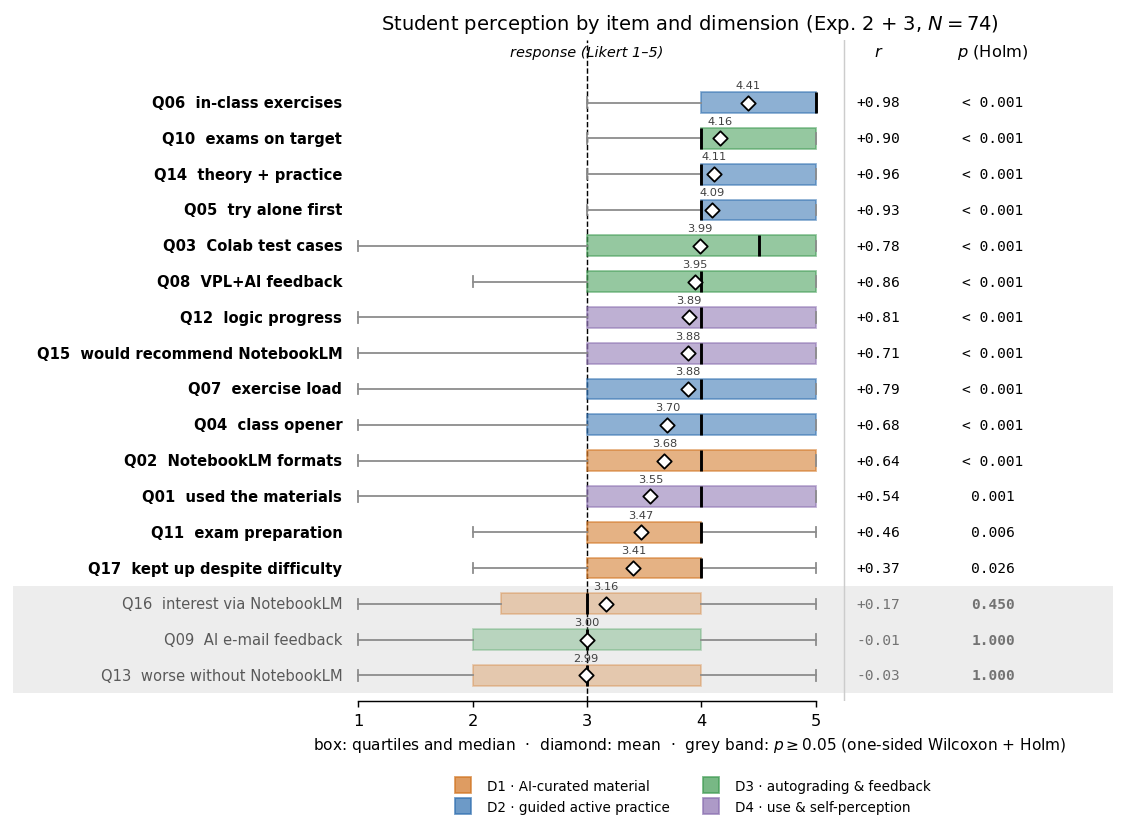

In [21]:
figs.fig_percepcao_dimensoes()
display(Image(filename=str(ROOT / "figuras" / "fig_percepcao_dimensoes_en.png")))


**📄 In the article.** Figure 5 (`figuras/fig_percepcao_dimensoes_en.pdf`,
generated by `analise/03_figuras_en.py::fig_percepcao_dimensoes` — called
directly above).

### 3.7 Homogeneity Experiment 2 x Experiment 3 (Mann-Whitney U + Holm)

Justifies combining the two groups: if no substantive item differs
between Instructor B (daytime) and Instructor C (evening), the pooling is
legitimate. (This used to be its own figure — medians by instructor; now
it is just the test, mentioned in Figure 5's caption.)

In [22]:
# Holm applied to the FULL family of instrument items (Q01-Q20), as in the
# article's analysis; the count of "differences" is read among the substantive ones.
homo = []
for q in sorted(QMAP):
    b = col(av[av.experiment == "Exp. 2"], q)
    c = col(av[av.experiment == "Exp. 3"], q)
    u = stats.mannwhitneyu(b, c, alternative="two-sided")
    homo.append(dict(item=q, median_B=np.median(b), median_C=np.median(c),
                     U=float(u.statistic), p_raw=float(u.pvalue)))
homo = pd.DataFrame(homo)
homo["p_holm"] = multipletests(homo["p_raw"], method="holm")[1]
homo["differs"] = homo["p_holm"] < 0.05
subst_homo = homo[homo.item.isin(SUBST)]
print(homo.to_string(index=False, float_format="{:.4f}".format))
print(f"\n{int(subst_homo.differs.sum())}/17 substantive items differ between B and C after Holm "
      f"-> {'legitimate pooling' if subst_homo.differs.sum() == 0 else 'ATTENTION'}")
print("  (note: Q07 is borderline — p_raw≈0.003; p_holm≈0.05 if the correction uses "
      "only the 17 substantive items and ≈0.055 over the 20 items)")
check("0/17 substantive items differ (B x C)", subst_homo.differs.sum(), 0, tol=0)


item  median_B  median_C         U  p_raw  p_holm  differs
 Q01    4.0000    4.0000  613.0000 0.4564  1.0000    False
 Q02    4.0000    4.0000  656.0000 0.7916  1.0000    False
 Q03    5.0000    4.0000  679.0000 0.9953  1.0000    False
 Q04    4.0000    4.0000  614.0000 0.4610  1.0000    False
 Q05    4.0000    4.0000  801.5000 0.1629  1.0000    False
 Q06    5.0000    4.0000  909.0000 0.0051  0.0863    False
 Q07    4.0000    4.0000  942.0000 0.0029  0.0547    False
 Q08    4.0000    4.0000  767.0000 0.3246  1.0000    False
 Q09    3.0000    3.0000  839.5000 0.0690  0.8975    False
 Q10    5.0000    4.0000  776.0000 0.2656  1.0000    False
 Q11    3.5000    4.0000  568.0000 0.2125  1.0000    False
 Q12    4.0000    4.0000  750.0000 0.4274  1.0000    False
 Q13    2.5000    3.0000  425.5000 0.0045  0.0804    False
 Q14    4.0000    4.0000  814.0000 0.1230  1.0000    False
 Q15    4.0000    4.0000  647.0000 0.7109  1.0000    False
 Q16    3.0000    3.0000  486.5000 0.0299  0.4487    Fal

**📄 In the article.** §4.3.1 — "revealed no difference in any of the
17 substantive items; only one checker (Q19) differed … legitimises the
pooling". (Q07 is borderline — see the note above.)

### 3.8 Internal consistency — Cronbach's alpha (Q01-Q17)

In [23]:
M = av[[QMAP[q] for q in SUBST]].apply(pd.to_numeric, errors="coerce")
a_all = cronbach(M)
a_B = cronbach(M[av.experiment == "Exp. 2"])
a_C = cronbach(M[av.experiment == "Exp. 3"])
print(f"Cronbach's alpha (Q01-Q17):  Exp. 2+3 = {a_all:.3f}   Exp. 2 = {a_B:.3f}   Exp. 3 = {a_C:.3f}")
check("combined Cronbach ~0.89", a_all, 0.89, tol=0.02)


Cronbach's alpha (Q01-Q17):  Exp. 2+3 = 0.890   Exp. 2 = 0.883   Exp. 3 = 0.906
  [OK ] combined Cronbach ~0.89: obtained=0.8896722290184818  article≈0.89


**📄 In the article.** §4.3.1 — "Cronbach's alpha for Q01-Q17 was
$\alpha = 0.89$ in the combined group (0.88 in Experiment 2; 0.91 in
Experiment 3)".

### 3.9 Hierarchical clustering (HCA) x *a priori* dimensions

Pearson correlation matrix among the 17 items → distance $d = 1 - r$ →
average linkage (UPGMA). The dendrogram is cut at $k = 4$ and the
empirical partition is compared with the D1-D4 dimensions using the
**Rand index**.

empirical clusters (k=4):
  C1: ['Q03', 'Q05', 'Q06', 'Q07', 'Q12', 'Q14']
  C2: ['Q01', 'Q02', 'Q04', 'Q11', 'Q13', 'Q15', 'Q16', 'Q17']
  C3: ['Q09', 'Q10']
  C4: ['Q08']
dim      D1  D2  D3  D4
cluster                
1         0   4   1   1
2         5   1   0   2
3         0   0   2   0
4         0   0   1   0

Rand index (a priori dimensions x clusters) = 0.73
  [OK ] Rand a priori vs HCA ~0.73: obtained=0.7279411764705882  article≈0.73


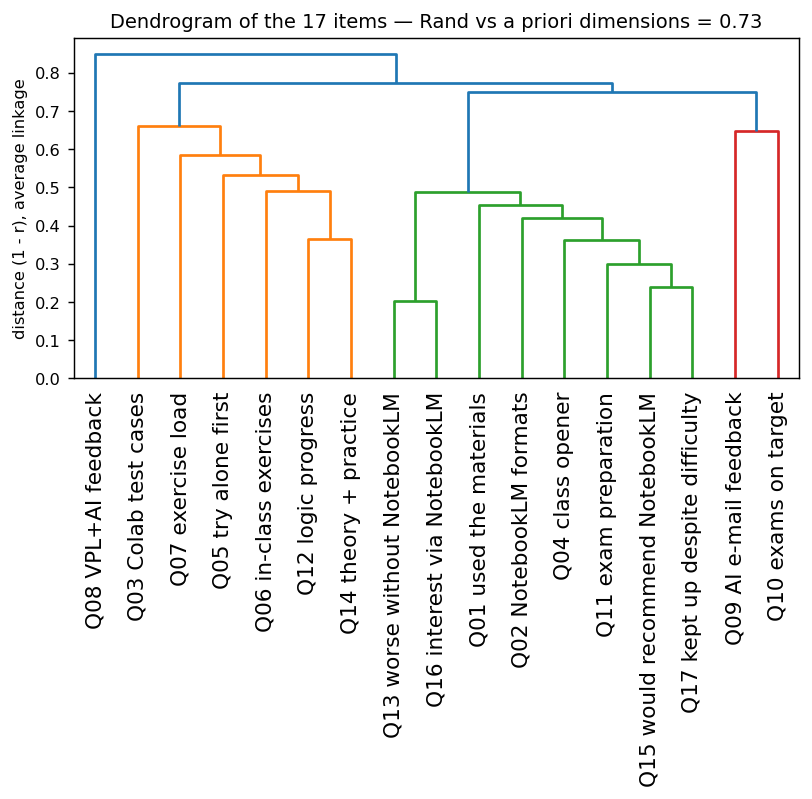

In [24]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from itertools import combinations

MQ = pd.DataFrame({q: col(av, q) for q in SUBST})
Rmat = MQ.corr(method="pearson")
Dm = 1 - Rmat.values
np.fill_diagonal(Dm, 0.0); Dm = (Dm + Dm.T) / 2
Z = linkage(squareform(Dm, checks=False), method="average")

apriori = [DIM_OF[q] for q in SUBST]
cl4 = fcluster(Z, 4, criterion="maxclust")

def rand_index(a, b):
    n = len(a); ok = sum((a[i] == a[j]) == (b[i] == b[j]) for i, j in combinations(range(n), 2))
    return ok / (n * (n - 1) / 2)

ri = rand_index(apriori, list(cl4))
print("empirical clusters (k=4):")
for c in sorted(set(cl4)):
    print(f"  C{c}: {[SUBST[i] for i in range(len(SUBST)) if cl4[i] == c]}")
print(pd.crosstab(pd.Series(cl4, name='cluster'), pd.Series(apriori, name='dim')))
print(f"\nRand index (a priori dimensions x clusters) = {ri:.2f}")
check("Rand a priori vs HCA ~0.73", ri, 0.73, tol=0.05)

fig, ax = plt.subplots(figsize=(7.2, 3.4))
dendrogram(Z, labels=[f"{q} {MNEM[q]}" for q in SUBST], leaf_rotation=90,
           color_threshold=0.7, ax=ax)
ax.set_ylabel("distance (1 - r), average linkage")
ax.set_title(f"Dendrogram of the 17 items — Rand vs a priori dimensions = {ri:.2f}")
plt.tight_layout(); plt.show()


**📄 In the article.** §4.3.1 — "Hierarchical clustering ($k=4$)
partially recovers the \emph{a priori} dimensions (Rand index 0.73): D2
emerges cohesive, the items of D1 and D4 merge into a single branch, and
Q08 stands out on its own".

### 3.10 Power analysis

The article makes a **qualitative** claim (reference: Cohen, 1988): the
pooling of Experiments 2 and 3 ($N = 74$) has power **adequate for large
effects** ($r \ge 0.5$) and **close to adequate for medium effects**
($r \approx 0.3$); the isolated experiments ($N = 16, 34, 40$) fall short
of that. Below, an **independent Monte Carlo** check: Likert responses are
generated with a shift calibrated to two effect sizes ($r \approx 0.3$
and $r \approx 0.5$), and the fraction of rejections is counted. The
expected pattern: for $r \approx 0.5$, power is already high at $N = 74$;
for $r \approx 0.3$, it is borderline; the small $N$'s are underpowered
in both cases.

In [25]:
def generate_likert(n, shift, sd=1.05):
    return np.clip(np.round(RNG.normal(3 + shift, sd, n)), 1, 5)

# calibrates the shift for two rank-biserial targets
grid = np.linspace(0.0, 1.6, 33)
rr = [np.mean([rank_biserial(generate_likert(400, s)) for _ in range(40)]) for s in grid]
shift = {0.3: float(np.interp(0.30, rr, grid)), 0.5: float(np.interp(0.50, rr, grid))}
print(f"calibrated shifts: r≈0.3 -> {shift[0.3]:.3f} | r≈0.5 -> {shift[0.5]:.3f}\n")

def power_mc(n, s, reps=3000):
    hit = 0
    for _ in range(reps):
        try:
            hit += stats.wilcoxon(generate_likert(n, s) - 3, alternative="greater").pvalue < 0.05
        except ValueError:
            pass
    return hit / reps

print(f"  {'N':>3} | {'power r≈0.3':>12} | {'power r≈0.5':>12}")
mc = {}
for n in (16, 34, 40, 74):
    p3, p5 = power_mc(n, shift[0.3]), power_mc(n, shift[0.5])
    mc[n] = (p3, p5)
    print(f"  {n:>3} | {p3*100:>10.0f} % | {p5*100:>10.0f} %")
assert mc[74][1] > 0.8, "power for a large effect at N=74 should be high"
assert mc[74][0] < mc[74][1], "medium effect should give less power than large"
assert mc[16][1] < mc[74][1], "small N should have less power"
print("\n-> confirms the article's qualitative pattern: N=74 covers large "
      "effects well, is borderline for medium ones; small N's are underpowered.")


calibrated shifts: r≈0.3 -> 0.254 | r≈0.5 -> 0.445

    N |  power r≈0.3 |  power r≈0.5


   16 |         23 % |         46 %


   34 |         38 % |         74 %


   40 |         43 % |         82 %


   74 |         63 % |         97 %

-> confirms the article's qualitative pattern: N=74 covers large effects well, is borderline for medium ones; small N's are underpowered.


**📄 In the article.** §4.3 (Method) — "the pooling of Experiments 2
and 3 ($N=74$) has power adequate to detect large effects ($r \ge 0.5$)
and close to adequate for medium effects ($r \approx 0.3$)".

### 3.11 Experiment 1 — descriptive analysis

Its own instrument (22 items); an item-by-item comparison with Q01-Q17
would need a semantic mapping (not tabulated) and is **not** reproduced
(as in the article). Only the *direction* of responses is checked.

In [26]:
it1 = likert_cols(g1)
med1 = pd.Series({qid(c): np.median(pd.to_numeric(g1[c], errors="coerce").dropna()) for c in it1})
print("medians per item (Experiment 1's own item numbering):")
print(med1.to_string())
print(f"\nitems with median >= 4: {(med1 >= 4).sum()}/{len(med1)}  "
      f"-> direction mostly of agreement, consistent with Exp. 2+3")


medians per item (Experiment 1's own item numbering):
Q01    4.0
Q02    5.0
Q03    3.0
Q04    5.0
Q05    5.0
Q06    4.0
Q07    4.5
Q08    5.0
Q09    5.0
Q10    4.0
Q11    5.0
Q12    4.0
Q13    3.0
Q14    5.0
Q15    4.0
Q16    5.0
Q17    4.0
Q18    4.0
Q19    5.0
Q20    2.0
Q21    1.0
Q22    5.0

items with median >= 4: 18/22  -> direction mostly of agreement, consistent with Exp. 2+3


**📄 In the article.** §4.3.3 — "analysed only descriptively … the
direction of responses is consistent with that of the other
experiments".

### 3.12 Items without effect (Q09, Q13, Q16)

A closer look at the three substantive items that **don't** reach
significance: individualised e-mail feedback (Q09), "without NotebookLM,
learning would have been worse" (Q13), and "NotebookLM increased
interest" (Q16).

In [27]:
print(conf.loc[conf.item.isin(["Q09", "Q13", "Q16"]),
      ["item", "median", "r", "p_raw", "p_holm", "signif"]].to_string(index=False))
q09 = conf.loc[conf.item == "Q09"].iloc[0]
check("Q09 not significant", bool(q09.signif), False, tol=0)
check("Q09 r ~ 0 (|r|<0.1)", abs(q09.r) < 0.1, True, tol=0)


item  median     r    p_raw   p_holm  signif
 Q09     3.0 -0.01 0.521380 1.000000   False
 Q13     3.0 -0.03 0.567692 1.000000   False
 Q16     3.0  0.17 0.149839 0.449516   False
  [OK ] Q09 not significant: obtained=False  article≈False
  [OK ] Q09 r ~ 0 (|r|<0.1): obtained=True  article≈True


**📄 In the article.** §4.3.2 — "the items without a statistical
effect are treated separately"; Q09 "($r=-0.01$; $p = 0.52$)".

---
# Part 4 — Traceability map

Final table: every number in the article → the value recomputed here →
where it appears.

In [28]:
trace = pd.DataFrame([
    ("Series: number of classes",         len(d),                         "§4.1 / §4.2 / Tab. 6", "1.2"),
    ("Series: assessments",               int(d.n_assessed.sum()),        "§4.1",                 "1.2"),
    ("Global failure rate (pooled)",      f"{glob*100:.1f}%",             "§4.1",                 "1.4"),
    ("Daytime / evening (pooled)",        f"{pool(d[d['shift']=='daytime'])*100:.1f}% / {pool(d[d['shift']=='evening'])*100:.1f}%", "§4.2", "1.5"),
    ("On-schedule term / other terms",    f"{pool(d[d.on_schedule==1])*100:.1f}% / {pool(d[d.on_schedule==0])*100:.1f}%", "§4.1", "1.5"),
    ("Baseline Exp. 1 / 2 / 3",           f"{base['Exp. 1 (Instr. A)']*100:.1f}% / {base['Exp. 2 (Instr. B)']*100:.1f}% / {base['Exp. 3 (Instr. C)']*100:.1f}%", "§4.1", "1.5"),
    ("Shift x term — on-schedule (daytime/evening, OR)",
     f"{term_split['on-schedule']['daytime']['rate']*100:.1f}% / {term_split['on-schedule']['evening']['rate']*100:.1f}%; OR={term_split['on-schedule']['or']:.2f}",
     "§4.1 / Fig. 4", "1.11"),
    ("Shift x term — other terms (daytime/evening, OR)",
     f"{term_split['other terms']['daytime']['rate']*100:.1f}% / {term_split['other terms']['evening']['rate']*100:.1f}%; OR={term_split['other terms']['or']:.2f}",
     "§4.1 / Fig. 4", "1.11"),
    ("Paired Wilcoxon (term)",            f"{(diff>0).sum()}/{len(diff)}; p={w_series.pvalue:.1e}", "§4.2", "1.7"),
    ("GLM OR shift (base)",               f"{or0:.2f} [{ci0[0]:.2f}; {ci0[1]:.2f}]", "§4.2",     "1.8"),
    ("GLM OR shift (+campus / +on-schedule)", f"{or1:.2f} / {or2:.2f}",       "§4.2",                 "1.8"),
    ("SRH shift (H, p)",                  f"H={srh['shift'][0]:.1f}; p={srh['shift'][2]:.1e}", "§4.2", "1.9"),
    ("Profile: daytime not employed",     f"{no_d}/{n_d} ({no_d/n_d:.0%})", "§4.1",             "2"),
    ("Profile: evening employed",         f"{yes_e}/{n_e} ({yes_e/n_e:.0%})", "§4.1",             "2"),
    ("Perception: N (Exp.2 / 3 / 1)",     f"{(av.experiment=='Exp. 2').sum()} / {(av.experiment=='Exp. 3').sum()} / {len(g1)}", "§4.3 / Tab. 4", "3.1"),
    ("Items violating normality",         f"{viol}/{len(norm)}",          "§4.3",                 "3.3"),
    ("Wilcoxon+Holm: significant items",  f"{n_sig}/17",               "§4.3.1 / Fig. 5",      "3.4"),
    ("Homogeneity BxC: substantive items that differ", f"{int(subst_homo.differs.sum())}/17", "§4.3.1", "3.7"),
    ("HCA vs a priori dimensions (Rand)", f"{ri:.2f}",                 "§4.3.1",               "3.9"),
    ("Highest/lowest-scoring dimension", f"{dims.loc[dims.mean_score.idxmax(),'dimension'][:2]} / {dims.loc[dims.mean_score.idxmin(),'dimension'][:2]}", "§4.3.1", "3.5"),
    ("Cronbach (Q01-Q17)",               f"{a_all:.2f}",                 "§4.3.1",               "3.9"),
    ("Items without effect",             "Q09, Q13, Q16",                "§4.3.2",               "3.12"),
], columns=["result", "recalculated value", "location in article", "cell"])
trace


,result,recalculated value,location in article,cell
0,Series: number of classes,840,§4.1 / §4.2 / Tab. 6,1.2
1,Series: assessments,25797,§4.1,1.2
2,Global failure rate (pooled),30.2%,§4.1,1.4
3,Daytime / evening (pooled),25.8% / 35.5%,§4.2,1.5
4,On-schedule term / other terms,27.5% / 40.5%,§4.1,1.5
5,Baseline Exp. 1 / 2 / 3,32.1% / 23.0% / 37.3%,§4.1,1.5
6,"Shift x term — on-schedule (daytime/evening, OR)",22.8% / 33.2%; OR=1.68,§4.1 / Fig. 4,1.11
7,"Shift x term — other terms (daytime/evening, OR)",37.0% / 45.0%; OR=1.39,§4.1 / Fig. 4,1.11
8,Paired Wilcoxon (term),29/32; p=8.6e-08,§4.2,1.7
9,GLM OR shift (base),1.57 [1.40; 1.76],§4.2,1.8


---
### How to re-run / maintain

```bash
python3 analise/gen_notebook_calculos_en.py                      # regenerates this .ipynb
jupyter nbconvert --to notebook --execute --inplace analise/artigo_calculos_en.ipynb
jupyter nbconvert --ClearOutputPreprocessor.enabled=True --to notebook \
        --inplace analise/artigo_calculos_en.ipynb                # clear outputs before committing
```

The `check(...)` calls halt execution if any number diverges from the
article beyond the tolerance — they serve as a regression test for the
analysis.